Маємо невелику ділянку зображення:

        сусіди
     ┌───────────┐
     │  10  20  10
     │  20 100  20
     │  10  20  10
     └───────────┘
          ↑
       pixel

Gaussian Filter обчислює зважене середнє пікселів в ядрі, при цьому ближчі до центру пікселі мають більшу вагу:

      1     4     1
      4    16     4
      1     4     1


Після нормалізації:

    1/36  4/36  1/36
    4/36 16/36  4/36
    1/36  4/36  1/36


## типові випадки використання:

* **видалення шуму**

        Image
          ↓
        Gaussian Blur
          ↓
        Cleaner Image

* **Перед edge detection**

        Image
          ↓
        GaussianBlur
          ↓
        Canny
          ↓
        Edges

* **Перед image gradients**

        Image
          ↓
        Gaussian Blur
          ↓
        Sobel
          ↓
        Gradient

* **low-pass filter** - пропускає низькі частоти та пригнічує високі частоти


            Gaussian Blur
                  │
                  ▼
             зменшує шум
                  │
                  ▼
           згладжує зображення
                  │
                  ▼
      прибирає дрібні деталі
                  │
                  ▼
       покращує preprocessing
                  │
          ┌───────┴────────┐
          ▼                ▼
        Canny            Sobel
        Edges           Gradients

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from core.entities.constants import Paths as p

### Visualisation

In [2]:
def get_gaussian_kernel(size: int, sigma: int):
    kernel = cv2.getGaussianKernel(size, sigma)
    kernel = np.outer(kernel, kernel)
    return kernel

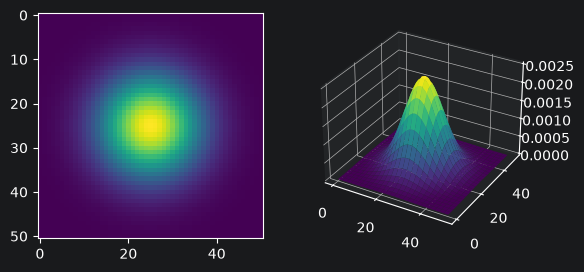

In [3]:
N = 51
SIGMA = 8

# 2D representation
fig = plt.figure()
plt.subplot(121)
kernel = get_gaussian_kernel(N, SIGMA)
plt.imshow(kernel)

#3D representation
ax = fig.add_subplot(122, projection='3d')
x = np.arange(0, N, 1)
y = np.arange(0, N, 1)
X, Y = np.meshgrid(x, y)

ax.plot_surface(X, Y, kernel, cmap="viridis")

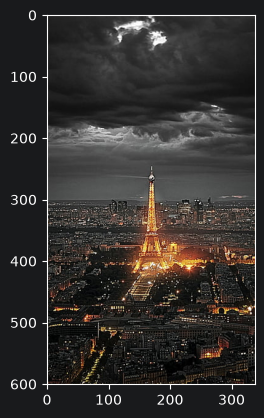

In [4]:
img_path = p.IMAGE_ASSETS / "paris.jpg"
img = cv2.imread(img_path)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure()
plt.imshow(img_rgb)

In [5]:
def gaus_filter_callback(value):
    pass

In [9]:
window_name = "Gaussian filter"
cv2.namedWindow(window_name)

In [10]:
cv2.createTrackbar("sigma", window_name, 1, 20, gaus_filter_callback)
cv2.createTrackbar("k_size", window_name, 1, 21, gaus_filter_callback)

while True:
    if cv2.waitKey(1) == ord("q"):
        break

    sigma = cv2.getTrackbarPos("sigma", window_name)
    if sigma == 0:
        sigma = 1
        cv2.setTrackbarPos("sigma", window_name, sigma)

    k_size = cv2.getTrackbarPos("k_size", window_name)

    if k_size % 2 == 0:
        k_size += 1
        cv2.setTrackbarPos("k_size", window_name, k_size)

    filtered = cv2.GaussianBlur(img, (k_size, k_size), sigma)
    cv2.imshow(window_name, filtered)

cv2.destroyAllWindows()